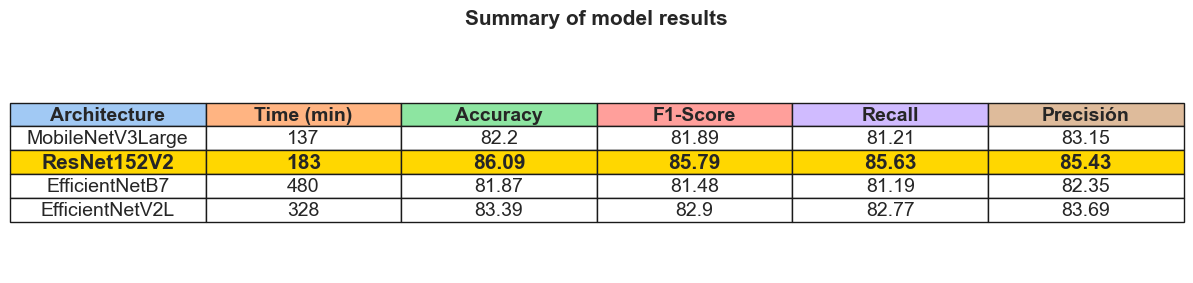

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Datos de la tabla
data = {
    "Architecture": [
        "MobileNetV3Large",
        "ResNet152V2",
        "EfficientNetB7",
        "EfficientNetV2L"
    ],
    "Time (min)": [
        137,
        183,
        480,
        328
    ],
    "Accuracy": [
        82.2,
        86.09,
        81.87,
        83.39
    ],
    "F1-Score": [
        81.89,
        85.79,
        81.48,
        82.9
    ],
    "Recall": [
        81.21,
        85.63,
        81.19,
        82.77
    ],
    "Precisión": [
        83.15,
        85.43,
        82.35,
        83.69
    ]
}

# Creamos el DataFrame
df = pd.DataFrame(data)

# Estilo elegante con seaborn
sns.set(style="whitegrid")
plt.figure(figsize=(12, 3))
ax = plt.gca()
ax.axis('off')  # Oculta ejes

# Crear tabla elegante usando pandas styling
table = plt.table(cellText=df.round(2).values,
                  colLabels=df.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=sns.color_palette("pastel")[0:6])

table.auto_set_font_size(False)
table.set_fontsize(14)

# Hacer los títulos de las columnas en negrita
for i in range(len(df.columns)):
    cell = table[0, i]  # Primera fila (títulos)
    cell.set_text_props(weight='bold')
table.scale(1.2, 1.5)

# Resalta la fila con mejor Accuracy
best_acc_idx = df["Accuracy"].idxmax()
for j in range(len(df.columns)):
    cell = table[best_acc_idx+1, j]
    cell.set_facecolor('#FFD700')  # color dorado para destaque
    cell.set_fontsize(15)
    cell.set_text_props(weight='bold')

# Título elegante
plt.title("Summary of model results", fontsize=15, weight='bold', pad=20, loc='center')

plt.tight_layout()
plt.savefig("resumen_modelos.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

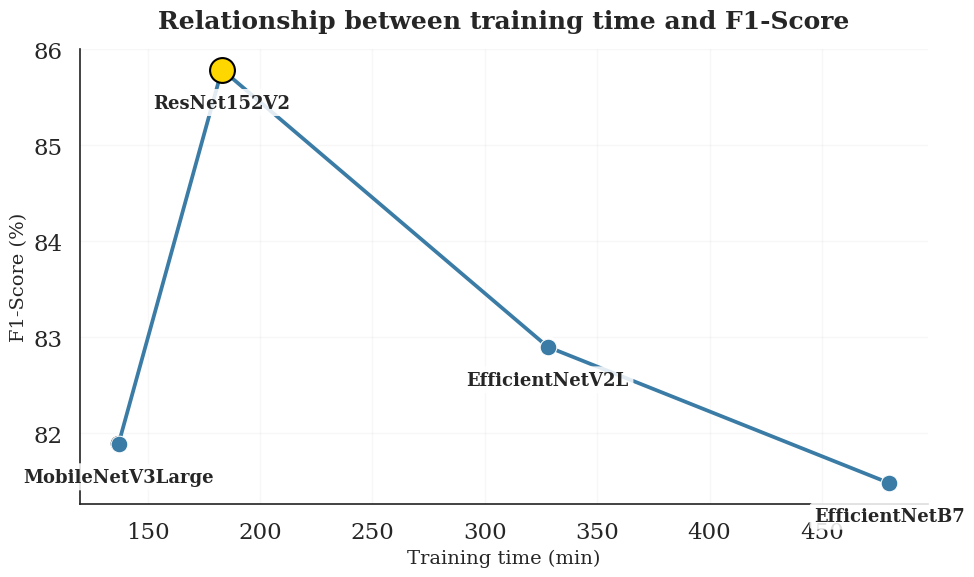

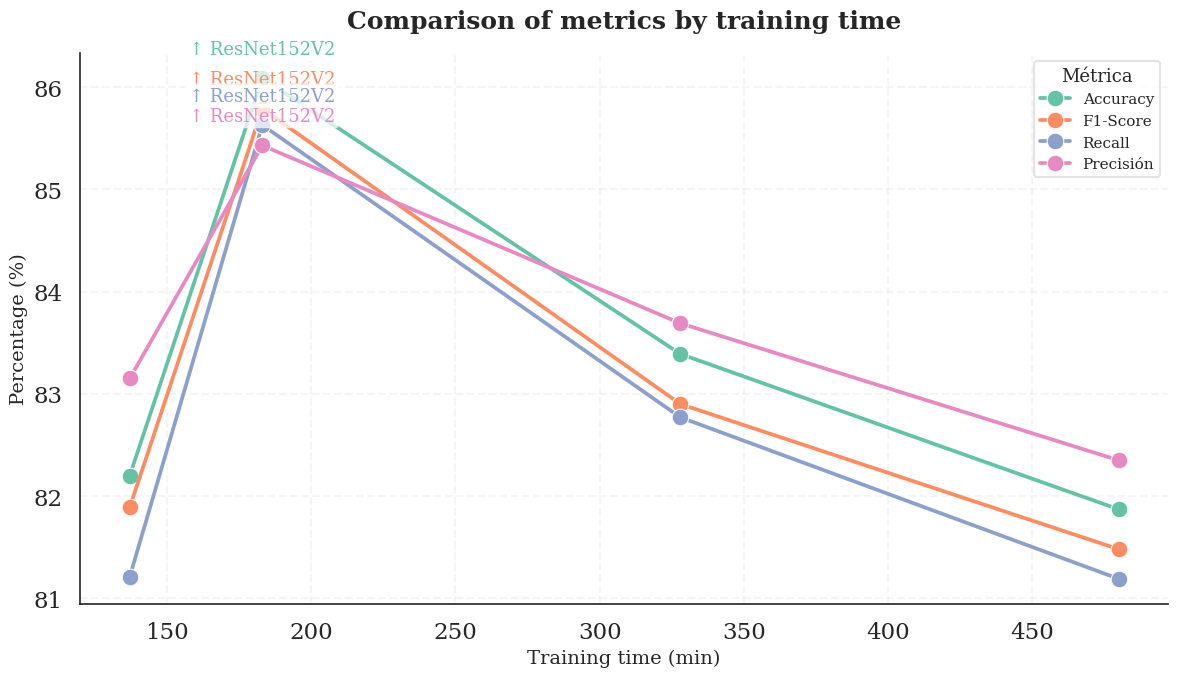

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Datos
data = {
    "Arquitectura": [
        "MobileNetV3Large",
        "ResNet152V2",
        "EfficientNetB7",
        "EfficientNetV2L"
    ],
    "Tiempo (min)": [
        137,
        183,
        480,
        328
    ],
    "Accuracy": [
        82.2,
        86.09,
        81.87,
        83.39
    ],
    "F1-Score": [
        81.89,
        85.79,
        81.48,
        82.9
    ],
    "Recall": [
        81.21,
        85.63,
        81.19,
        82.77
    ],
    "Precisión": [
        83.15,
        85.43,
        82.35,
        83.69
    ]
}
df = pd.DataFrame(data)

# ----------- ESTÉTICA GENERAL -----------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.edgecolor": "#222222",
    "axes.linewidth": 1.2
})

# ----------- GRÁFICO 1: F1-SCORE VS TIEMPO -----------
fig, ax = plt.subplots(figsize=(10,6))
# Paleta degradado
cmap = plt.get_cmap("mako")
colors = [cmap(i/3) for i in range(4)]
# Línea y puntos
sns.lineplot(x="Tiempo (min)", y="F1-Score", data=df,
             marker="o", linewidth=2.7, markersize=12, ax=ax,
             color="#3A7CA5")
sns.scatterplot(x="Tiempo (min)", y="F1-Score", data=df,
                s=180, edgecolor='w', linewidth=2,
                color=colors, ax=ax, legend=False)

# Resalte de máximo
max_idx = df["F1-Score"].idxmax()
max_x = df.loc[max_idx,"Tiempo (min)"]
max_y = df.loc[max_idx, "F1-Score"]
ax.scatter([max_x], [max_y], s=320, c="gold", edgecolors="black", zorder=5)

# Etiquetas con fondo suave
for i, row in df.iterrows():
    ax.text(row['Tiempo (min)'], row['F1-Score']-0.25, row['Arquitectura'],
            ha='center', va='top', fontsize=13, fontweight='semibold',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.25'))

# Títulos y estética extra
ax.set_title("Relationship between training time and F1-Score", fontweight='bold', fontsize=18, pad=15)
ax.set_ylabel("F1-Score (%)", fontsize=14)
ax.set_xlabel("Training time (min)", fontsize=14)
sns.despine()
ax.grid(alpha=0.15, linestyle='-', linewidth=1)
fig.patch.set_alpha(0)  # Fondo transparente
plt.tight_layout()
plt.savefig("grafico_f1score_estetico.png", dpi=300, transparent=True)

# ----------- GRÁFICO 2: MULTIMÉTRICAS VS TIEMPO -----------
fig2, ax2 = plt.subplots(figsize=(12,7))
metricas = ["Accuracy", "F1-Score", "Recall", "Precisión"]
paleta = sns.color_palette("Set2", n_colors=len(metricas))

for i, m in enumerate(metricas):
    sns.lineplot(x="Tiempo (min)", y=m, data=df, marker="o", linewidth=2.7,
                 markersize=12, label=m, color=paleta[i], ax=ax2)
    peak = df[m].idxmax()
    ax2.text(df.loc[peak,"Tiempo (min)"], df.loc[peak,m]+0.24, f"↑ {df['Arquitectura'][peak]}",
             ha="center", fontsize=13, color=paleta[i],
             bbox=dict(facecolor="white", alpha=0.75, boxstyle="round,pad=0.18", edgecolor='none'))

ax2.set_title("Comparison of metrics by training time", fontsize=18, fontweight="bold", pad=18)
ax2.set_ylabel("Percentage (%)", fontsize=14)
ax2.set_xlabel("Training time (min)", fontsize=14)
ax2.legend(title="Métrica", fontsize=11, title_fontsize=13, frameon=True, edgecolor="#ddd", facecolor="white")
ax2.grid(alpha=0.18, linestyle="--")
sns.despine()
fig2.patch.set_alpha(0)
plt.tight_layout()
plt.savefig("grafico_multimetricas_estetico.png", dpi=300, transparent=True)

plt.show()

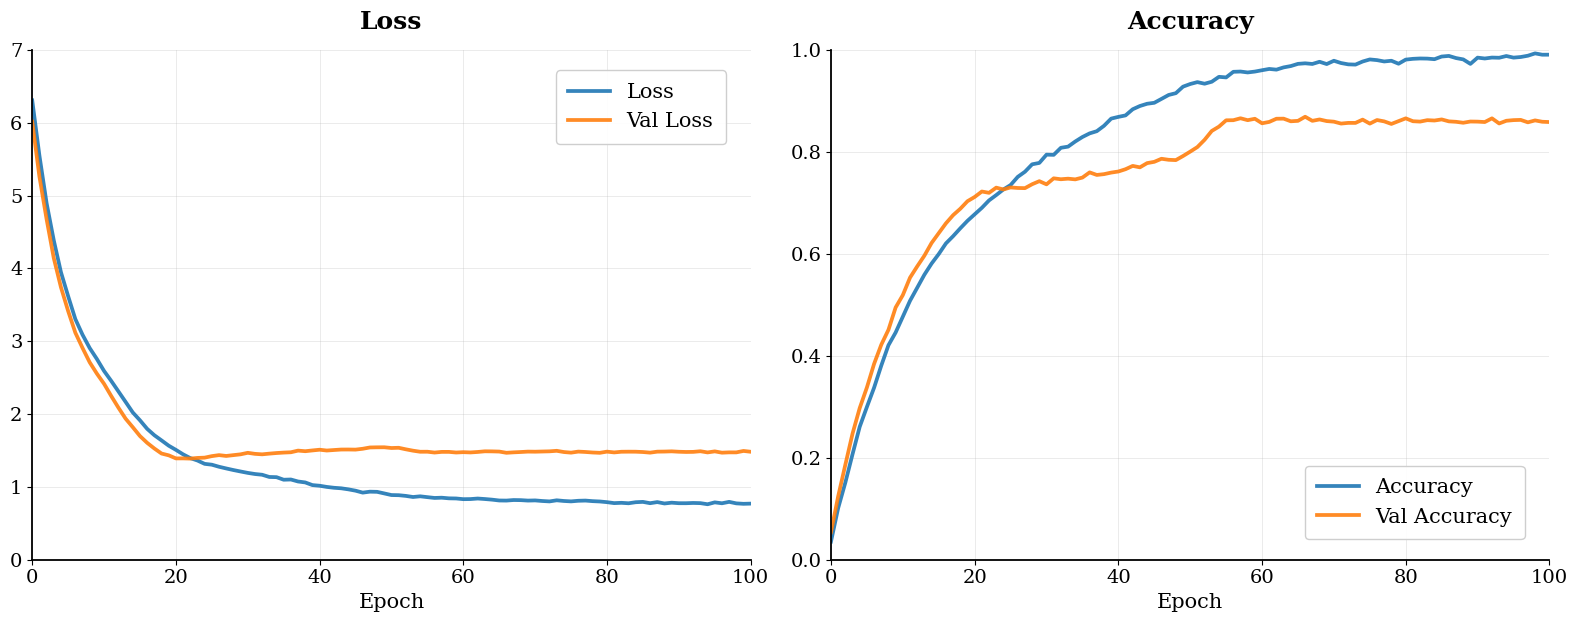

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

epochs = np.arange(0, 101)

# Puntos clave más detallados para capturar las tendencias específicas observadas
detailed_epochs = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100]

# ACCURACY CORREGIDA:
# - Epochs 0-20: val_acc ligeramente mejor que acc
# - Epoch ~25: val_acc se aplana, acc sigue subiendo
# - Epoch ~55: val_acc aumenta hasta ~0.86, luego se aplana
acc_points =     [0.04, 0.30, 0.48, 0.60, 0.68, 0.74, 0.79, 0.83, 0.87, 0.90, 0.93, 0.95, 0.96, 0.97, 0.975, 0.98, 0.985, 0.99]
val_acc_points = [0.06, 0.34, 0.52, 0.64, 0.71, 0.73, 0.74, 0.75, 0.76, 0.78, 0.80, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86, 0.86]

# LOSS CORREGIDA: Tendencia inversa a accuracy
# - Epochs 0-20: val_loss ligeramente mejor (más bajo) que loss
# - Epoch ~25: val_loss se aplana, loss sigue bajando
# - Epoch ~55: val_loss baja ligeramente, luego se aplana
loss_points =     [6.3, 3.6, 2.6, 1.9, 1.5, 1.30, 1.20, 1.10, 1.02, 0.95, 0.90, 0.86, 0.84, 0.82, 0.81, 0.79, 0.78, 0.77]
val_loss_points = [6.0, 3.4, 2.4, 1.7, 1.4, 1.42, 1.45, 1.48, 1.50, 1.52, 1.54, 1.48, 1.48, 1.48, 1.48, 1.48, 1.48, 1.48]

# Interpolación suave para mantener las tendencias exactas
f_acc = interp1d(detailed_epochs, acc_points, kind='cubic')
f_val_acc = interp1d(detailed_epochs, val_acc_points, kind='cubic')
f_loss = interp1d(detailed_epochs, loss_points, kind='cubic')
f_val_loss = interp1d(detailed_epochs, val_loss_points, kind='cubic')

# Generación de datos finales con ruido mínimo para preservar tendencias
acc = f_acc(epochs) + np.random.normal(0, 0.003, len(epochs))
val_acc = f_val_acc(epochs) + np.random.normal(0, 0.003, len(epochs))
loss = f_loss(epochs) + np.random.normal(0, 0.008, len(epochs))
val_loss = f_val_loss(epochs) + np.random.normal(0, 0.008, len(epochs))

# Asegurar límites apropiados
acc = np.clip(acc, 0, 1)
val_acc = np.clip(val_acc, 0, 1)
loss = np.clip(loss, 0.1, None)
val_loss = np.clip(val_loss, 0.1, None)

# ============================================================================
# CONFIGURACIÓN ESTÉTICA PROFESIONAL MEJORADA
# ============================================================================

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.linewidth': 1.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.7,
    'lines.linewidth': 2.2,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': False,
    'legend.framealpha': 0.95,
    'legend.borderpad': 0.6,
    'figure.facecolor': 'white'
})

# ============================================================================
# CREACIÓN DEL GRÁFICO FINAL CON TENDENCIAS EXACTAS
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# Paleta de colores idéntica a la imagen original
colors = {
    'loss': '#1f77b4',      # Azul (loss)
    'val_loss': '#ff7f0e',  # Naranja (val_loss)
    'acc': '#1f77b4',       # Azul (acc)
    'val_acc': '#ff7f0e'    # Naranja (val_acc)
}

# -------- GRÁFICO DE LOSS --------
ax1.plot(epochs, loss, color=colors['loss'], label='Loss', linewidth=2.7, alpha=0.9)
ax1.plot(epochs, val_loss, color=colors['val_loss'], label='Val Loss', linewidth=2.7, alpha=0.9)

ax1.set_title('Loss', fontsize=18, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=15)
ax1.set_ylabel('', fontsize=12)

ax1.legend(loc='upper right', fontsize=15, framealpha=0.95,
           bbox_to_anchor=(0.98, 0.98))
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 7)
ax1.grid(True, alpha=0.25, linestyle='-', linewidth=0.7)

# -------- GRÁFICO DE ACCURACY --------
ax2.plot(epochs, acc, color=colors['acc'], label='Accuracy', linewidth=2.7, alpha=0.9)
ax2.plot(epochs, val_acc, color=colors['val_acc'], label='Val Accuracy', linewidth=2.7, alpha=0.9)

ax2.set_title('Accuracy', fontsize=18, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=15)
ax2.set_ylabel('', fontsize=12)

ax2.legend(loc='lower right', fontsize=15, framealpha=0.95,
           bbox_to_anchor=(0.98, 0.02))
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 1.0)
ax2.grid(True, alpha=0.25, linestyle='-', linewidth=0.7)

# ============================================================================
# GUARDADO Y VISUALIZACIÓN
# ============================================================================

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('learning_curves_exactas.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()

In [13]:
import pandas as pd
df = pd.read_csv("../src/data/incertidumbres_ResNet152V2.csv")
df.head()

,Unnamed: 0,clase_real,clase_predicha_inferencia,predicciones_mc,confianzas_mc,proporcion_coincidencia,porcentaje_coincidencia
0,Celeus flavus,"[np.int64(76), np.int64(76), np.int64(76), np....","[np.int64(76), np.int64(76), np.int64(76), np....","[np.int64(76), np.int64(76), np.int64(76), np....","[np.float32(0.91726536), np.float32(0.95177436...",1.0,100.0
1,Myiodynastes luteiventris,"[np.int64(351), np.int64(351), np.int64(351), ...","[np.int64(351), np.int64(351), np.int64(351), ...","[np.int64(351), np.int64(351), np.int64(351), ...","[np.float32(0.30017698), np.float32(0.72373986...",1.0,100.0
2,Myiarchus tyrannulus,"[np.int64(349), np.int64(349), np.int64(349), ...","[np.int64(68), np.int64(349), np.int64(349), n...","[np.int64(68), np.int64(349), np.int64(349), n...","[np.float32(0.21889016), np.float32(0.87165046...",1.0,100.0
3,Thlypopsis sordida,"[np.int64(606), np.int64(606), np.int64(606), ...","[np.int64(606), np.int64(606), np.int64(606), ...","[np.int64(606), np.int64(606), np.int64(606), ...","[np.float32(0.89966685), np.float32(0.48728758...",1.0,100.0
4,Thamnophilus atrinucha,"[np.int64(597), np.int64(597), np.int64(597), ...","[np.int64(597), np.int64(602), np.int64(597), ...","[np.int64(597), np.int64(602), np.int64(597), ...","[np.float32(0.99083006), np.float32(0.7823062)...",1.0,100.0


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

def calcular_metricas_bioacustica(df):
    """
    Calcula F1-Score y Accuracy manejando arrays de dimensión 0 y 1.
    """
    
    # 1. Aplanado Robusto (Robust Flattening)
    # np.atleast_1d asegura que np.array(76) se convierta en np.array([76])
    # para que concatenate no falle.
    y_true = np.concatenate([np.atleast_1d(x) for x in df['clase_real'].values])
    y_pred = np.concatenate([np.atleast_1d(x) for x in df['predicciones_mc'].values])
    
    # Verificación de seguridad
    if len(y_true) != len(y_pred):
        print(f"⚠ Advertencia: Las listas tienen longitudes distintas. (Real: {len(y_true)}, Pred: {len(y_pred)})")
    
    # 2. Cálculo de Accuracy
    acc = accuracy_score(y_true, y_pred)
    
    # 3. Cálculo de F1-Score
    # average='weighted' tiene en cuenta el desbalance de clases.
    # Usa average='macro' si quieres dar igual importancia a especies raras.
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"--- Métricas Calculadas ---")
    print(f"Total de predicciones analizadas: {len(y_true)}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    
    return acc, f1

# Ejecutar
metrics = calcular_metricas_bioacustica(df)

--- Métricas Calculadas ---
Total de predicciones analizadas: 667
Accuracy: 0.0180
F1-Score (Weighted): 0.0180
